In [80]:
using DifferentialEquations
using FindPeaks1D
using Interpolations
using Plots
using FFTW
using LinearAlgebra
using JLD
using Statistics
using QuadGK
using FastGaussQuadrature
using LaTeXStrings
using NumericalIntegration
using Random
using Distributions 
using CairoMakie

In [28]:
# Parameters for type 1 distribution
κ_s1 = 1.0
Δ_a1 = 0.2 * κ_s1
Δ_b1 = -0.2 * κ_s1
g_31 = 0.1 * κ_s1
g_41 = 0.003
S1 = 0 + 0.7im
η_sig1 = [0.2/sqrt(2), 0.2/sqrt(2)]
η_id1 = [0.2/sqrt(2), 0.2/sqrt(2)]
φ_sig1 = [0,  π/2]
φ_id1  = [π/2, π]
n_sig1 = [1.5, 1.5]
n_id1 = [1.5, 1.5]
p1 = (
    Δ_a1 = Δ_a1,
    Δ_b1 = Δ_b1,
    κ_s1 = κ_s1,
    g_31 = g_31,
    g_41 = g_41,
    S1 = S1,
    n_sig1 = n_sig1,
    n_id1 = n_id1,
    η_sig1 = η_sig1,
    η_id1 = η_id1,
    φ_sig1 = φ_sig1,
    φ_id1 = φ_id1
)

(Δ_a1 = 0.2, Δ_b1 = -0.2, κ_s1 = 1.0, g_31 = 0.1, g_41 = 0.003, S1 = 0.0 + 0.7im, n_sig1 = [1.5, 1.5], n_id1 = [1.5, 1.5], η_sig1 = [0.1414213562373095, 0.1414213562373095], η_id1 = [0.1414213562373095, 0.1414213562373095], φ_sig1 = [0.0, 1.5707963267948966], φ_id1 = [1.5707963267948966, 3.141592653589793])

In [29]:
# Parameters for type 2 distribution
κ_s2 = 1.0
Δ_a2 = 0.2 * κ_s1
Δ_b2 = -0.2 * κ_s1
g_32 = 0.1 * κ_s1
g_42 = 0.003
S2 = 0 + 0.7im
η_sig2 = [0.2/sqrt(2), 0.2/sqrt(2)]
η_id2 = [-0.2/sqrt(2), -0.2/sqrt(2)]
φ_sig2 = [0,  π/2]
φ_id2  = [-π/2, 0]
n_sig2 = [1.5, 1.5]
n_id2 = [1.5, 1.5]
p2 = (
    Δ_a2 = Δ_a2,
    Δ_b2 = Δ_b2,
    κ_s2 = κ_s2,
    g_32 = g_32,
    g_42 = g_42,
    S2 = S2,
    n_sig2 = n_sig2,
    n_id2 = n_id2,
    η_sig2 = η_sig2,
    η_id2 = η_id2,
    φ_sig2 = φ_sig2,
    φ_id2 = φ_id2
)

(Δ_a2 = 0.2, Δ_b2 = -0.2, κ_s2 = 1.0, g_32 = 0.1, g_42 = 0.003, S2 = 0.0 + 0.7im, n_sig2 = [1.5, 1.5], n_id2 = [1.5, 1.5], η_sig2 = [0.1414213562373095, 0.1414213562373095], η_id2 = [-0.1414213562373095, -0.1414213562373095], φ_sig2 = [0.0, 1.5707963267948966], φ_id2 = [-1.5707963267948966, 0.0])

In [30]:
function stochastic_point(t, dt, p)
    Δ_a, Δ_b, κ_s, g_3, g_4, S, n_sig, n_id, η_sig, η_id, φ_sig, φ_id = p
    # Generate two independent Wiener increments dW,1 and dW,2
    dW_shared = randn(2) * sqrt(dt) 

    # Correlated noise-driven terms
    
     # dW_shared[1] for index 1, dW_shared[2] for index 2 for both sig and id
    noise_α = sum(sqrt(κ_s) * (η_sig[j] + sqrt(n_sig[j]) * dW_shared[j]) * exp(-im * φ_sig[j]) for j in 1:2)
    noise_β = sum(sqrt(κ_s) * (η_id[j] + sqrt(n_id[j]) * dW_shared[j]) * exp(-im * φ_id[j]) for j in 1:2)

    # dW_shared[1] for sig_1 and id_2 , dW_shared[2] for sig_2 and id_1
    noise_α_cross = sqrt(κ_s) * (η_sig[1] + sqrt(n_sig[1]) * dW_shared[1]) * exp(-im * φ_sig[1])  + sqrt(κ_s) * (η_sig[2] + sqrt(n_sig[2]) * dW_shared[2]) * exp(-im * φ_sig[2])
    noise_β_cross = sqrt(κ_s) * (η_id[1] + sqrt(n_id[1]) * dW_shared[2]) * exp(-im * φ_id[1]) + sqrt(κ_s) * (η_id[2] + sqrt(n_id[2]) * dW_shared[1]) * exp(-im * φ_id[2])

    return noise_α, noise_β, noise_α_cross, noise_β_cross
end

stochastic_point (generic function with 1 method)

In [31]:
# Generate some stochastic input
function input_trajectory(p)
    total_t = 1.0
    dt = 1e-3
    N = Int(total_t/dt) # number of time steps
    t = range(0, stop = total_t, length = N) # discrete time steps
    
    sig_input_vals = ComplexF64[]
    id_input_vals = ComplexF64[]

    sig_input_vals_cross = ComplexF64[]
    id_input_vals_cross = ComplexF64[]
    for i in 1:N
        sig_input, id_input, sig_input_cross, id_input_cross = stochastic_point(t[i], dt, p)
        push!(sig_input_vals, sig_input)
        push!(id_input_vals, id_input)
        push!(sig_input_vals_cross, sig_input_cross)
        push!(id_input_vals_cross, id_input_cross)
    end
    return sig_input_vals, id_input_vals, sig_input_vals_cross, id_input_vals_cross, t
end

input_trajectory (generic function with 1 method)

In [32]:
# transform input from type 1 (or type 2) into I and Q  quadratures, for visualization
sig_input1, id_input1,_,_,t = input_trajectory(p1) # can swap for p2
sig_i = real((1/sqrt(2)).*(sig_input1 + conj(sig_input1)))
sig_q = real((-1im/sqrt(2)).*(sig_input1 - conj(sig_input1)))
id_i = real((1/sqrt(2)).*(id_input1 + conj(id_input1)))
id_q = real((-1im/sqrt(2)).*(id_input1 - conj(id_input1)))

1000-element Vector{Float64}:
 -0.2075921123079432
 -0.3076647877284222
 -0.17845648962955182
 -0.12133245043602649
 -0.24281432477034542
 -0.27996016232884
 -0.18360429685835064
 -0.2674952866237648
 -0.22434520320540383
 -0.1601904165239891
 -0.2429178469059289
 -0.14308969715807804
 -0.17191535343744518
  ⋮
 -0.20602281349454193
 -0.23069498984996542
 -0.19885843606813242
 -0.31620816236590676
 -0.2751847563529874
 -0.11614955977260975
 -0.2443571600268886
 -0.21534081042522588
 -0.2720131450348025
 -0.11738719632441441
 -0.19683935462050306
 -0.19170626641086844

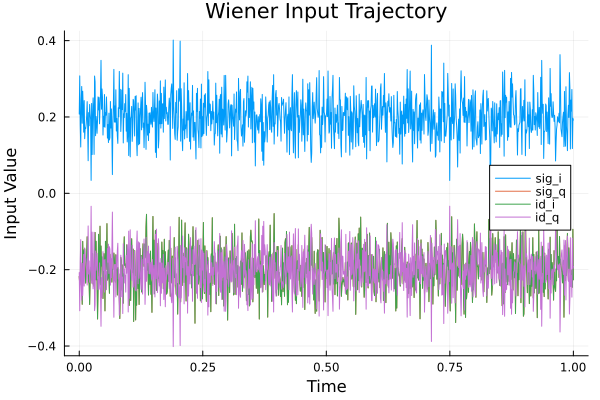

In [33]:
plot((t, sig_i), label = "sig_i")
plot!((t,sig_q), label = "sig_q")
plot!((t,id_i), label = "id_i")
plot!((t,id_q), label = "id_q", legend =:right, title = "Wiener Input Trajectory", ylabel = "Input Value", xlabel = "Time")


In [34]:
# variance-constant, mean time dependent input time averaging
function time_averaging(p)
    total_t = 1.0
    dt = 1e-3
    N = Int(total_t/dt) # number of time steps
    t = range(0, stop = total_t, length = N) # discrete time steps
    
    sig_sum = 0.0 + 0im
    id_sum = 0.0 + 0im

    sig_sum_cross = 0.0 + 0im
    id_sum_cross = 0.0 + 0im
    
    for i in 1:N
        sig_input, id_input, sig_input_cross, id_input_cross = stochastic_point(t[i], dt, p)

        # Time average noise
        sig_sum += sig_input
        id_sum += id_input
        
        sig_sum_cross += sig_input_cross
        id_sum_cross += id_input_cross
    end
    #print(sig_sum)
    sig_avg = sig_sum/sqrt(N)
    id_avg = id_sum/sqrt(N)
    
    sig_avg_cross = sig_sum_cross/sqrt(N)
    id_avg_cross = id_sum_cross/sqrt(N)

    return sig_avg, id_avg, sig_avg_cross, id_avg_cross
    
    #println("Time averaged sig input: $sig_avg")
    #println("Time averaged id input: $id_avg")
end 


time_averaging (generic function with 1 method)

In [35]:
# get input shots for both Type 1 and Type 2
num_shots = 200
sig_i1 = []
sig_q1  = []
id_i1 = []
id_q1 = []

sig_i2 = []
sig_q2  = []
id_i2 = []
id_q2 = []


for i in 1:num_shots
    sig_avg1, id_avg1, sig_avg_cross1, id_avg_cross1 = time_averaging(p1)
    push!(sig_i1, real((1/sqrt(2)).*(sig_avg1 + conj(sig_avg1))))
    push!(sig_q1, real((-1im/sqrt(2)).*(sig_avg1 - conj(sig_avg1))))
    push!(id_i1, real((1/sqrt(2)).*(id_avg1 + conj(id_avg1))))
    push!(id_q1, real((-1im/sqrt(2)).*(id_avg1 - conj(id_avg1))))
    
    sig_avg2, id_avg2, sig_avg_cross2, id_avg_cross2 = time_averaging(p2)
    push!(sig_i2, real((1/sqrt(2)).*(sig_avg2 + conj(sig_avg2))))
    push!(sig_q2, real((-1im/sqrt(2)).*(sig_avg2 - conj(sig_avg2))))
    push!(id_i2, real((1/sqrt(2)).*(id_avg2 + conj(id_avg2))))
    push!(id_q2, real((-1im/sqrt(2)).*(id_avg2 - conj(id_avg2))))

end


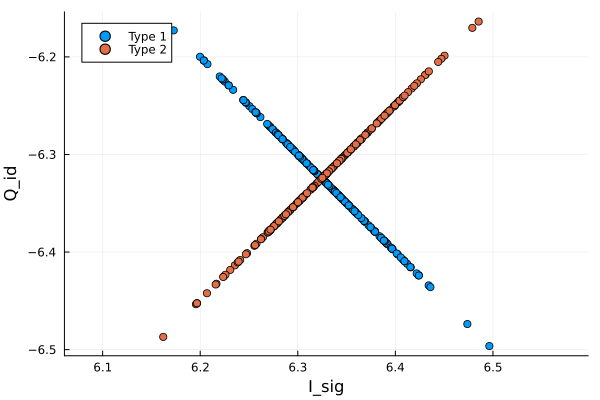

In [36]:
# visualize cross-quadrature inputs (expect this to show orthogonal squeezing)
scatter(sig_i1, id_q1, axis_ratio=:equal, label = "Type 1")
scatter!(sig_i2, id_q2, label = "Type 2", xlabel = "I_sig", ylabel = "Q_id")

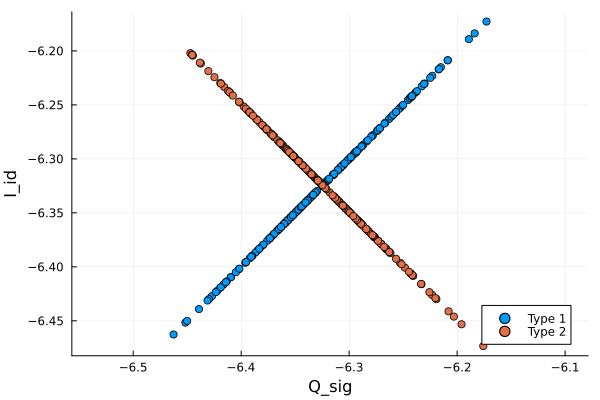

In [37]:
scatter(sig_q1, id_i1, axis_ratio=:equal, label = "Type 1")
scatter!(sig_q2, id_i2, label = "Type 2", xlabel = "Q_sig", ylabel = "I_id")

In [38]:
# saves direct quadrature stochastic point generated noise 
function stochastic_series(tsteps::AbstractVector, dt::Float64, p)
    N = length(tsteps)
    noise_α_array = Vector{ComplexF64}(undef, N)
    noise_β_array = Vector{ComplexF64}(undef, N)

    for i in 1:N
        t = tsteps[i]
        noise_α, noise_β, _, _,_ = stochastic_point(t, dt, p)
        noise_α_array[i] = noise_α
        noise_β_array[i] = noise_β
    end

    return noise_α_array, noise_β_array
end

stochastic_series (generic function with 1 method)

In [39]:
# stochastic solver, linearized (no g4) 
function f_linear!(du, u, p, t)
    Δ_a, Δ_b, κ_s, g_3, g_4, S, n_sig, n_id, η_sig, η_id, φ_sig, φ_id = p
    α, β = u[1], u[2]

    du[1] = (1im * Δ_a - κ_s / 2) * α + 1im * 6 * g_3 * S * conj(β) 
    for i in 1:2
        du[1] += sqrt(κ_s) * η_sig[i] * exp(-1im * φ_sig[i])
    end

    du[2] = (1im * Δ_b - κ_s / 2) * β + 1im * 6 * g_3 * S * conj(α) 
    for j in 1:2
        du[2] += sqrt(κ_s) * η_id[j] *
        exp(-1im * φ_id[j])
    end
end

function g_dir!(du, u, p, t)
    Δ_a, Δ_b, κ_s, g_3, g_4, S, n_sig, n_id, η_sig, η_id, φ_sig, φ_id = p
    du .= 0.0 + 0.0im  # size should be (2, 2), 2 equations, 2 Wiener noises

    for i in 1:2
        # α noise from signal channel, note
        du[1, i] = sqrt(κ_s * n_sig[i]) * exp(-1im * φ_sig[i])

        # β noise from idler channel, same dW[k] for correlated noise
        du[2, i] = sqrt(κ_s * n_id[i]) * exp(-1im * φ_id[i])
    end
end

function g_cross!(du, u, p, t)
     Δ_a, Δ_b, κ_s, g_3, g_4, S, n_sig, n_id, η_sig, η_id, φ_sig, φ_id = p
    du .= 0.0 + 0.0im  # clear diffusion matrix

    # α gets same noise pattern as before
    for i in 1:2
        
        du[1, i] = sqrt(κ_s * n_sig[i]) * exp(-1im * φ_sig[i])
    end

    # β receives cross-coupled noise
    du[2, 1] = sqrt(κ_s * n_id[2]) * exp(-1im * φ_id[2])
    du[2, 2] = sqrt(κ_s * n_id[1]) * exp(-1im * φ_id[1])
end


g_cross! (generic function with 1 method)

In [40]:
# stochastic solver, full with g4 
function f_full!(du, u, p, t)
     Δ_a, Δ_b, κ_s, g_3, g_4, S, n_sig, n_id, η_sig, η_id, φ_sig, φ_id = p
    α, β = u[1], u[2]

    absS2 = abs2(S)
    absα2 = abs2(α)
    absβ2 = abs2(β)

    du[1] = (1im * Δ_a - κ_s / 2) * α + 1im * 6 * g_3 * S * conj(β) +
            1im * 12 * g_4 * absα2 * α + 
            1im * 24 * g_4 * (absS2 * α + absβ2 * α)

    for i in 1:2
        du[1] += sqrt(κ_s) * η_sig[i] * exp(-1im*φ_sig[i])
    end

    du[2] = (1im * Δ_b - κ_s / 2) * β + 1im * 6 * g_3 * S * conj(α) + 
            1im * 12 * g_4 * absβ2 * β + 
            1im * 24 * g_4 * (absS2 * β + absα2 * β)


    for j in 1:2
        du[2] += sqrt(κ_s) * η_id[j] * exp(-1im*φ_id[j])
    end
end

f_full! (generic function with 1 method)

In [41]:
# define SDE solutions for Type 1 and Type 2 
A = zeros(ComplexF64, 2, 2)  # size for noise (i and q for both dir and cross)
prob_dir1 = SDEProblem(f_full!, g_dir!, [0.0 + 0.0im, 0.0 + 0.0im], (0.0, 200.0), p1, noise_rate_prototype = A)
prob_dir2 = SDEProblem(f_full!, g_dir!, [0.0 + 0.0im, 0.0 + 0.0im], (0.0, 200.0), p2, noise_rate_prototype = A)

SDEProblem with uType Vector{ComplexF64} and tType Float64. In-place: true
timespan: (0.0, 200.0)
u0: 2-element Vector{ComplexF64}:
 0.0 + 0.0im
 0.0 + 0.0im

In [42]:
# solve output trajectory for Type 1 
sol_dir_SDE1 = solve(prob_dir1, EM(), dt = 1e-3, save_noise=true) 

t_vals1 = sol_dir_SDE1.t
α_stochastic1 = sol_dir_SDE1[1,:]
β_stochastic1 = sol_dir_SDE1[2,:]

α_stochastic_real1 = real.(α_stochastic1)
α_stochastic_imag1 = imag.(α_stochastic1)
β_stochastic_real1 = real.(β_stochastic1)
β_stochastic_imag1 = imag.(β_stochastic1)




200001-element Vector{Float64}:
  0.0
 -0.0002881460624533613
 -0.014059841946757003
 -0.018220013235348886
 -0.10241493446835345
 -0.08391733583216746
 -0.0831866672780954
 -0.12188671456566257
 -0.10706956203879493
 -0.11029531700051332
 -0.13538378978673984
 -0.08120453548133055
 -0.07049149605140298
  ⋮
 -0.7636139987466226
 -0.7335058678112242
 -0.7511386301119649
 -0.7337058962930801
 -0.7069202352767571
 -0.7384416766621902
 -0.7809458966556494
 -0.7590875509858434
 -0.7497059805987301
 -0.7664063593744692
 -0.7648207294396437
 -0.7627896148245465

In [43]:
# solve output trajectory for Type 2 
sol_dir_SDE2 = solve(prob_dir2, EM(), dt = 1e-3, save_noise=true) 

t_vals2 = sol_dir_SDE2.t
α_stochastic2 = sol_dir_SDE2[1,:]
β_stochastic2 = sol_dir_SDE2[2,:]

α_stochastic_real2 = real.(α_stochastic2)
α_stochastic_imag2 = imag.(α_stochastic2)
β_stochastic_real2 = real.(β_stochastic2)
β_stochastic_imag2 = imag.(β_stochastic2)


200001-element Vector{Float64}:
  0.0
 -0.055629604659684286
 -0.053808921232719624
 -0.07866702896618612
 -0.06569838661408234
 -0.08952595507100246
 -0.0892539930235176
 -0.0950668843074076
 -0.05119783905121948
 -0.010147515816818165
  0.0033975792410276904
 -0.014336073223414906
 -0.060339596788691094
  ⋮
 -1.5617199029103392
 -1.5884058184258916
 -1.5648924974830976
 -1.5664691453165558
 -1.5040737273548053
 -1.499964810087297
 -1.5290638788330868
 -1.49997550906041
 -1.5401057510403238
 -1.5281948839149142
 -1.5453504201907085
 -1.5452217954571017

In [ ]:
α_I1 = 

The previous step solved for 1 time trajectory, which is useful for visualizing. Next, we iterate this process to run many output shots.

In [44]:
function run_shots(p; u0, tspan, dt, cut, nshots, A)

    Δ_a, Δ_b, κ_s, g_3, g_4, S, n_sig, n_id, η_sig, η_id, φ_sig, φ_id = p

    tsteps = collect(tspan[1]:dt:tspan[2])

    input_sig  = zeros(ComplexF64, nshots)
    input_id   = zeros(ComplexF64, nshots)
    input_sig_i = zeros(Float64, nshots)
    input_sig_q = zeros(Float64, nshots)
    input_id_i  = zeros(Float64, nshots)
    input_id_q  = zeros(Float64, nshots)

    input_Isum  = zeros(Float64, nshots)
    input_Idiff = zeros(Float64, nshots)
    input_Qsum  = zeros(Float64, nshots)
    input_Qdiff = zeros(Float64, nshots)

    output_α_i = zeros(Float64, nshots)
    output_α_q = zeros(Float64, nshots)
    output_β_i = zeros(Float64, nshots)
    output_β_q = zeros(Float64, nshots)

    for shot in 1:nshots
        prob_stoch = SDEProblem(f_full!, g_dir!, u0, tspan, p, noise_rate_prototype=A)
        sol_stoch  = solve(prob_stoch, EM(), dt=dt, saveat=tsteps, save_noise=true)

        # Wiener increments
        W_vals = sol_stoch.W
        dW_vals = [W_vals[i+1] .- W_vals[i] for i in 1:length(W_vals)-1]

        # reconstruct noise terms
        α_noise_array = ComplexF64[]
        β_noise_array = ComplexF64[]

        for i in 1:length(dW_vals)
            t  = tsteps[i]
            u_here = sol_stoch.u[i]

            G = zeros(ComplexF64, 2, 2)
            g_dir!(G, u_here, p, t)

            dW = dW_vals[i]
            α_noise = G[1,1]*dW[1] + G[1,2]*dW[2]
            β_noise = G[2,1]*dW[1] + G[2,2]*dW[2]

            push!(α_noise_array, α_noise)
            push!(β_noise_array, β_noise)
        end

        # time-average noise (after transient)
        α_slice = α_noise_array[cut+1:end]
        β_slice = β_noise_array[cut+1:end]

        T_noise = length(α_slice) * dt
        scale_length = 1 / sqrt(T_noise)

        α_noise_sum = sum(α_slice)
        β_noise_sum = sum(β_slice)

        # deterministic η contribution (use κ_s, η_sig, φ_sig from p)
        α_eta = 1im * sqrt(κ_s) * sum(η_sig[i] * exp(-1im*φ_sig[i]) for i in 1:2)
        β_eta = 1im * sqrt(κ_s) * sum(η_id[j] * exp(-1im*φ_id[j]) for j in 1:2)

        input_sig[shot] = scale_length * α_noise_sum + α_eta
        input_id[shot]  = scale_length * β_noise_sum + β_eta

        # I/Q quadratures
        input_sig_i[shot] = real((input_sig[shot] + conj(input_sig[shot]))/sqrt(2))
        input_sig_q[shot] = real((-1im * (input_sig[shot] - conj(input_sig[shot])))/sqrt(2))
        input_id_i[shot]  = real((input_id[shot]  + conj(input_id[shot]))/sqrt(2))
        input_id_q[shot]  = real((-1im * (input_id[shot]  - conj(input_id[shot])))/sqrt(2))

        # sum and diff per shot
        input_Isum[shot]  = 0.5 * (input_sig_i[shot] + input_id_i[shot])
        input_Idiff[shot] = 0.5 * (input_sig_i[shot] - input_id_i[shot])
        input_Qsum[shot]  = 0.5 * (input_sig_q[shot] + input_id_q[shot])
        input_Qdiff[shot] = 0.5 * (input_sig_q[shot] - input_id_q[shot])

        # outputs after transient cutoff
        α_out_vals = [u[1] for u in sol_stoch.u[cut+1:end]]
        β_out_vals = [u[2] for u in sol_stoch.u[cut+1:end]]

        α_out_sum = sum(α_out_vals)
        β_out_sum = sum(β_out_vals)

        N_out = length(α_out_vals)
        T_out = N_out * dt
        scale_out = dt / sqrt(T_out)

        output_α_i[shot] = scale_out * real( (α_out_sum + conj(α_out_sum)) / sqrt(2) )
        output_α_q[shot] = scale_out * real( (-1im*(α_out_sum - conj(α_out_sum))) / sqrt(2) )
        output_β_i[shot] = scale_out * real( (β_out_sum + conj(β_out_sum)) / sqrt(2) )
        output_β_q[shot] = scale_out * real( (-1im*(β_out_sum - conj(β_out_sum))) / sqrt(2) )
    end

    return (
        input_sig   = input_sig,
        input_id    = input_id,
        input_sig_i = input_sig_i,
        input_sig_q = input_sig_q,
        input_id_i  = input_id_i,
        input_id_q  = input_id_q,
        input_Isum  = input_Isum,
        input_Idiff = input_Idiff,
        input_Qsum  = input_Qsum,
        input_Qdiff = input_Qdiff,
        output_α_i  = output_α_i,
        output_α_q  = output_α_q,
        output_β_i  = output_β_i,
        output_β_q  = output_β_q,
    )
end


run_shots (generic function with 1 method)

In [47]:
# run shots for Type 1 and Type 2 outputs
u0    = [0.0 + 0.0im, 0.0 + 0.0im]
tspan = (0.0, 300.0)
dt    = 1e-2
cut   = 100  # can scale this depending on S
nshots = 100 # can scale depending on how many shots wanted

res1 = run_shots(p1; u0=u0, tspan=tspan, dt=dt, cut=cut, nshots=nshots, A=A) # set 1
res2 = run_shots(p2; u0=u0, tspan=tspan, dt=dt, cut=cut, nshots=nshots, A=A) # set 2


(input_sig = ComplexF64[0.767183217185246 + 0.40117865688048127im, -0.8313468810041511 - 0.6627816587944706im, 1.320680591579164 - 1.2329329976771157im, 0.7748198394794596 - 1.191509911457316im, 1.2627654332738827 + 0.263147904322392im, 0.4912041838665774 - 0.3242928529783389im, 0.8558114077697885 + 0.4256537703725831im, -1.3438291815466428 + 0.3048000795041356im, -0.13461544972624956 - 0.2771354136196813im, 0.6582821696551073 - 1.1166567678064774im  …  0.3139713018430041 + 0.7232702202075074im, 1.547021878571301 + 0.21364490969089026im, 0.7158623742652923 - 1.4335575254689743im, -0.038348492919455024 - 0.6600033410819592im, -0.9696366384957682 + 0.7732427940098718im, -0.9820192012088291 - 0.696088775219811im, 0.5261183049868878 + 2.045066215388395im, -0.9103930666169253 - 0.8563604981170587im, -0.9594191942143542 + 0.5649319862491367im, 1.0549394264840675 + 0.31233712651625856im], input_id = ComplexF64[-0.11833594440586187 + 0.48434050471062623im, 0.9456243712690897 - 1.11418959347876

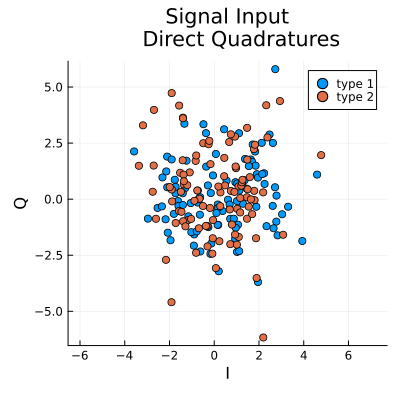

In [48]:
# Now we can visualize the different inputs, outputs with ease: 
scatter(res1.input_sig_i, res1.input_sig_q, axis_ratio=:equal, 
    label = "type 1")
scatter!(res2.input_sig_i, res2.input_sig_q, axis_ratio=:equal,
    label = "type 2",
    xlabel = "I",
    ylabel = "Q",
    title = "Signal Input
    Direct Quadratures", size = (400,400))

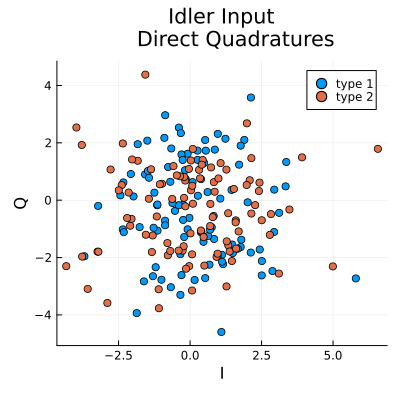

In [49]:
scatter(res1.input_id_i, res1.input_id_q, axis_ratio=:equal, 
    label = "type 1")
scatter!(res2.input_id_i, res2.input_id_q, axis_ratio=:equal,
    label = "type 2",
    xlabel = "I",
    ylabel = "Q",
    title = "Idler Input
    Direct Quadratures", size = (400,400))

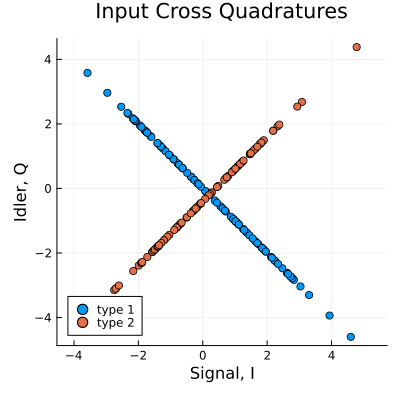

In [50]:
scatter(res1.input_sig_i, res1.input_id_q, axis_ratio=:equal, 
    label = "type 1 ")
scatter!(res2.input_sig_i, res2.input_id_q, axis_ratio=:equal,
    label = "type 2",
    xlabel = "Signal, I",
    ylabel = "Idler, Q",
    title = "Input Cross Quadratures",  size = (400,400), legend =:bottomleft)

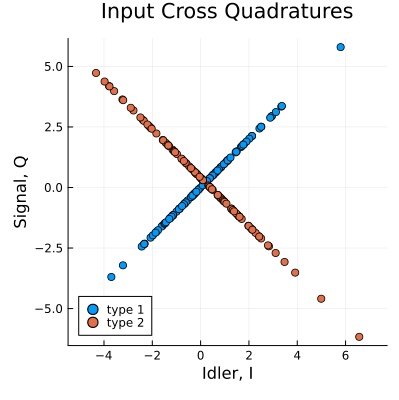

In [51]:
scatter(res1.input_id_i, res1.input_sig_q, axis_ratio=:equal, 
    label = "type 1 ")
scatter!(res2.input_id_i, res2.input_sig_q, axis_ratio=:equal,
    label = "type 2",
    xlabel = "Idler, I",
    ylabel = "Signal, Q",
    title = "Input Cross Quadratures",
    size = (400,400), legend=:bottomleft
    )

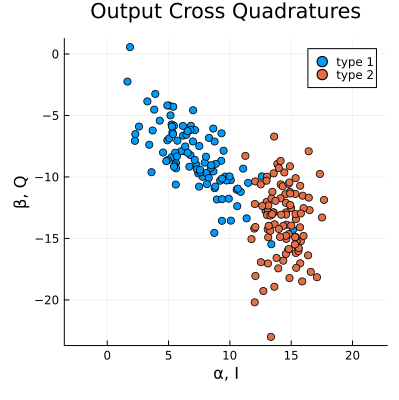

In [52]:
scatter(res1.output_α_i, res1.output_β_q, axis_ratio=:equal, label = "type 1")
scatter!(res2.output_α_i, res2.output_β_q, axis_ratio=:equal, label = "type 2",
    xlabel = "α, I", 
    ylabel = "β, Q", 
    title = "Output Cross Quadratures", 
    size = (400,400),
)

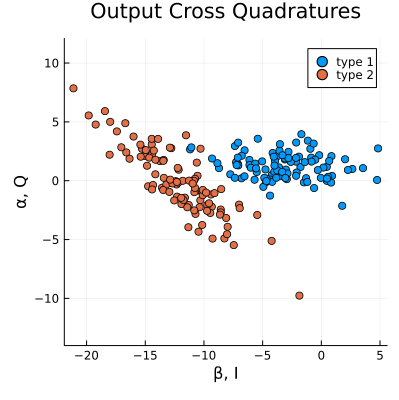

In [53]:
scatter(res1.output_β_i, res1.output_α_q, axis_ratio=:equal, label = "type 1")
scatter!(res2.output_β_i, res2.output_α_q, axis_ratio=:equal, label = "type 2",
    xlabel = "β, I", 
    ylabel = "α, Q", 
    title = "Output Cross Quadratures", size = (400,400)
)

Now, we move on to the Fisher discrminant step:

In [54]:
# implementation of within sample Fisher descriminant
# use the α and β quadratures outputs of the system that we have in res1 and res2, and calculate the fisher discriminant within them
# maximize variance between type 1 and type 2, minimize variance within each dataset class
# preliminary quantifies the separability of simulation results

function fisher_stats(X1::AbstractMatrix, X2::AbstractMatrix; ridge=1e-9)
    @assert size(X1,2) == size(X2,2) # should be true since we use the same input noise, but good to check 
    d = size(X1,2)

    # means of the input distributions 
    μ1 = vec(mean(X1; dims=1))
    μ2 = vec(mean(X2; dims=1))
    # mean diff
    Δμ = μ1 - μ2

    # covariances of the input distributions
    Σ1 = cov(X1; dims=1)
    Σ2 = cov(X2; dims=1)
    # within class covariance
    Sw = Σ1 + Σ2 + ridge * I(d)

    # Fisher direction (unit normalized)
    w = Sw \ Δμ
    w ./= norm(w)
    
    # Fisher separability 
    J = dot(Δμ, Sw \ Δμ)  
    return (J=J, w=w, μ1=μ1, μ2=μ2, Sw=Sw)
end


fisher_stats (generic function with 1 method)

In [55]:
# we can test out a 2D Fisher discriminant
# build feature matrices for the two plotted clusters
X_type1 = hcat(res1.output_β_i, res1.output_α_q)  
X_type2 = hcat(res2.output_β_i, res2.output_α_q)  

# Single-shot Fisher metric + direction
out = fisher_stats(X_type1, X_type2; ridge=1e-8)
println("Fisher J (βI vs αQ): ", out.J)
println("Fisher direction w = ", out.w)

Fisher J (βI vs αQ): 7.940463526814381
Fisher direction w = [0.672707945683523, 0.7399081157915854]


In [56]:
# we want more flexibility with what outputs (in terms of quadratures) we are finding the discrminant from 
# choose what you feed into Fisher/LDA
# note, these are 2D fisher lienar discrminations, so despite having the full 4D data, it does not contain the spatial nuance that we see later in the linear readout
function features_from_res(res; mode::Symbol = :aI_bQ)
    if mode == :aI_bQ
        X = hcat(res.output_α_i, res.output_β_q)
    elseif mode == :aQ_bI
        X = hcat(res.output_α_q, res.output_β_i)
    elseif mode == :all4
        X = hcat(res.output_α_i, res.output_α_q, res.output_β_i, res.output_β_q) 
    else
        error("unknown mode=$mode")
    end
    return X
end

features_from_res (generic function with 1 method)

In [62]:
# must enforce two-mode squeezing
const φsig_base = [0.0, π/2]
const φid_base_type1 = [π/2, π]     
const φid_base_type2 = [-π/2, 0.0]  

# helper function for rebuilding parameters during sweeps of parameter space 
function build_params(; base_p1, base_p2,
                      θ_sig=0.0, θ_id=0.0, θS=0.0,
                      absS=0.7, Λabs = 0.42, g4=0.001, Δsym = 0.2,
                      Δφ_id_between_types=0.0)

    # rewrite specified parameter field
    p1 = merge(base_p1, (
        Δ_a1 = +Δsym,
        Δ_b1 = -Δsym,
        φ_sig1 = φsig_base .+ θ_sig,
        φ_id1  = φid_base_type1 .+ θ_id,
        S1     = absS * cis(θS),
        g_31 = Λabs/(6 * S1),
        g_41   = g4,
    ))

    p2 = merge(base_p2, (
        Δ_a2 = +Δsym,
        Δ_b2 = -Δsym,
        φ_sig2 = φsig_base .+ θ_sig,
        φ_id2  = φid_base_type2 .+ θ_id .+ Δφ_id_between_types,
        S2     = absS * cis(θS),
        g_32 = Λabs/(6 * S2),
        g_42   = g4,
    ))

    return p1, p2
end

build_params (generic function with 1 method)

In [63]:
# we would like to evaluate trends for Fisher discrminants across different input values and generate error bars over n runs
# create some helper functions and otherwise fixed quantities that may be modified despite the sweep 

# running nshots and N times and evaluating the Fisher discrminant at each N 
function eval_point(; base_p1, base_p2,
                     θ_sig, θ_id, θS, Λabs, g4, Δsym,
                     absS=0.7,
                     Δφ_id_between_types=0.0,
                     feature_mode=:all4,
                     u0=[0.0+0im, 0.0+0im],
                     tspan=(0.0, 300.0), dt=1e-2, cut=100,
                     nshots=50,      # shots per run
                     N_runs=20,      # independent repeats for SE
                     A,
                     ridge=1e-9)
    p1, p2 = build_params(; base_p1, base_p2,
                            θ_sig=θ_sig, θ_id=θ_id, θS=θS,
                            absS=absS, Λabs=Λabs, g4=g4, Δsym=Δsym,
                            Δφ_id_between_types=Δφ_id_between_types)
    Js = Vector{Float64}(undef, N_runs)
    for k in 1:N_runs
        res1 = run_shots(p1; u0=u0, tspan=tspan, dt=dt, cut=cut, nshots=nshots, A=A)
        res2 = run_shots(p2; u0=u0, tspan=tspan, dt=dt, cut=cut, nshots=nshots, A=A)
        X1 = features_from_res(res1; mode=feature_mode)
        X2 = features_from_res(res2; mode=feature_mode)
        Js[k] = fisher_stats(X1, X2; ridge=ridge).J
    end
    Jmean = mean(Js)
    Jse   = std(Js) / sqrt(N_runs)
    return (J=Jmean, Jse=Jse, ci_lo=Jmean - 1.96*Jse, ci_hi=Jmean + 1.96*Jse)
end

eval_point (generic function with 1 method)

In [64]:
# Fixed parameters (all of which we may sweep) while keeping others constant. Will be rewritten later during sweep
fixed = (
    θsig = 0.0,
    θid  = 0.0,
    θS   = 0.0,
    g4   = 0.001,
    Λabs = 6 * p1.g_31 * 0.7,
    Δsym = p1.Δ_a1,
)
rng = MersenneTwister(1234) # use a seed for the random number generator to reduce noise between generators between shots
A   = zeros(ComplexF64, 2, 2)

2×2 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

In [65]:
# 1D sweep for some specified parameter
function sweep_1d(; vary::Symbol,
                    grid,
                    fixed,
                    base_p1, base_p2,
                    feature_mode=:all4,
                    nshots=30,
                    N_runs=20,
                    absS=0.7,
                    Δφ_id_between_types=0.0,
                    A)
    out = Vector{NamedTuple}(undef, length(grid))
    for (k, val) in enumerate(grid)
        θsig = fixed.θsig
        θid  = fixed.θid
        θS   = fixed.θS
        g4   = fixed.g4
        Λabs = fixed.Λabs
        Δsym = fixed.Δsym

        if     vary == :θsig;  θsig = val
        elseif vary == :θid;   θid  = val
        elseif vary == :θS;    θS   = val
        elseif vary == :g4;    g4   = val
        elseif vary == :Λabs;  Λabs = val
        elseif vary == :Δsym;  Δsym = val
        else   error("vary must be :θsig, :θid, :θS, :g4, :Λabs, or :Δsym")
        end

        # can comment out, just helpful since this tends to take slightly longer (a few minutes) to run
        println("  sweep point $k/$(length(grid)) | $vary = $val") 
        flush(stdout)

        ev = eval_point(; base_p1=base_p1, base_p2=base_p2,
                          θ_sig=θsig, θ_id=θid, θS=θS,
                          Λabs=Λabs, g4=g4, Δsym=Δsym,
                          absS=absS,
                          Δφ_id_between_types=Δφ_id_between_types,
                          feature_mode=feature_mode,
                          nshots=nshots, N_runs=N_runs, A=A)

        out[k] = (vary=vary, val=val,
                  θsig=θsig, θid=θid, θS=θS,
                  g4=g4, Λabs=Λabs, Δsym=Δsym,
                  J=ev.J, Jse=ev.Jse,
                  ci_lo=ev.ci_lo, ci_hi=ev.ci_hi)
    end
    return out
end

sweep_1d (generic function with 1 method)

In [66]:
# error bar plotting helper functions 
vals(s)  = [r.val   for r in s]
Jmean(s) = [r.J     for r in s]
Jse(s)   = [r.Jse   for r in s]
cilow(s) = [r.ci_lo for r in s]
cihi(s)  = [r.ci_hi for r in s]

function plot_sweep_ci(s; title="", xlabel="")
    x    = vals(s)
    y    = Jmean(s)
    lo   = cilow(s)
    hi   = cihi(s)
    yerr = (y .- lo, hi .- y)
    plot(x, y;
         seriestype = :scatter,
         yerror     = yerr,
         xlabel     = xlabel,
         ylabel     = "Fisher J (mean ± 1.96 SE)",
         title      = title,
         legend     = false)
end

plot_sweep_ci (generic function with 1 method)

  sweep point 1/13 | g4 = 0.0
  sweep point 2/13 | g4 = 0.0002916666666666667
  sweep point 3/13 | g4 = 0.0005833333333333334
  sweep point 4/13 | g4 = 0.000875
  sweep point 5/13 | g4 = 0.0011666666666666668
  sweep point 6/13 | g4 = 0.0014583333333333334
  sweep point 7/13 | g4 = 0.00175
  sweep point 8/13 | g4 = 0.0020416666666666665
  sweep point 9/13 | g4 = 0.0023333333333333335
  sweep point 10/13 | g4 = 0.002625
  sweep point 11/13 | g4 = 0.002916666666666667
  sweep point 12/13 | g4 = 0.0032083333333333334
  sweep point 13/13 | g4 = 0.0035


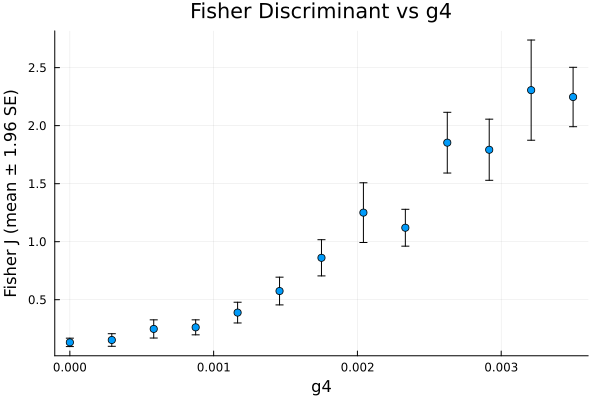

In [67]:
# example sweep of g4. all other parameters specified in the sweep_1d function can be swept this way. grids are adjusted based on physcial parameters
s_g4 = sweep_1d(; vary=:g4, grid=range(0, 0.0035; length=13),
                   fixed=fixed, base_p1=p1, base_p2=p2,
                   nshots=30, N_runs=20, A=A)

plot_sweep_ci(s_g4; title="Fisher Discriminant vs g4", xlabel="g4")

In [ ]:
# other example sweeps (these take quite long to run): 
s_sig = sweep_1d(; vary=:θsig, grid=range(0, 2π; length=13),
                   fixed=fixed, base_p1=p1, base_p2=p2,
                   nshots=30, N_runs=20, A=A)

plot_sweep_ci(s_sig; title="Fisher Discrminant vs θ_sig", xlabel="θ_sig (rad)")

In [ ]:
s_id = sweep_1d(; vary=:θid, grid=range(0, 2π; length=13),
                   fixed=fixed, base_p1=p1, base_p2=p2,
                   nshots=30, N_runs=20, A=A)

plot_sweep_ci(s_sig; title="Fisher Discrminant vs θ_id", xlabel="θ_id (rad)")

In [ ]:
s_s = sweep_1d(; vary=:θS, grid=range(0, 2π; length=13),
                   fixed=fixed, base_p1=p1, base_p2=p2,
                   nshots=30, N_runs=20, A=A)

plot_sweep_ci(s_s,title="Fisher Discriminant vs θ_S", xlabel="θ_S (rad)")

In [ ]:
s_delt = sweep_1d(; vary=:Δsym, grid=[1e-2, 0.5, 0.75, 1,2,3, 4],
                   fixed=fixed, base_p1=p1, base_p2=p2,
                   nshots=30, N_runs=20, A=A)

plot_sweep_ci(deltasym; title="Fisher Discriminant vs Δ", xlabel="Δ")

After getting a sense of what are the braod peformance metrics of the system using FDA, we can write our full 4D trained linear readout

In [68]:
# Define the two input matrices from Type 1 and Type 2 outputs: 
X1 = [
    res1.output_α_i';
    res1.output_α_q';
    res1.output_β_i';
    res1.output_β_q'
]

X2 = [
    res2.output_α_i';
    res2.output_α_q';
    res2.output_β_i';
    res2.output_β_q'
]


4×100 Matrix{Float64}:
  14.8888    14.143      14.6148   …   16.5935    13.1637     12.9883
   2.10797    0.417809   -2.21266      -4.91886   -0.103567    2.81146
 -15.0156   -10.5491     -9.33458      -9.26808  -12.3079    -12.902
 -11.2134   -10.6011    -13.8851      -17.719    -13.9763    -10.3043

In [69]:
# training function to get W
function train_tpp(X1::Matrix{Float64}, X2::Matrix{Float64}; λ=1e-10)
    N1, N2 = size(X1, 2), size(X2, 2)

    # get data matrix X_aug which is (5 × (2+2))
    # 5 comes from absorbing the Wx + b, b bias term into the fitting for W
    ones1 = ones(1, N1)
    ones2 = ones(1, N2)
    X_aug = hcat(
        vcat(X1, ones1),   # class 1 shots
        vcat(X2, ones2)    # class 2 shots
    )  

    # target classification matrix for each shot 
    # on-hot y vectors: class 1 → [1, 0],  Class 2 → [0, 1]
    Y = hcat(
        vcat(ones(1, N1), zeros(1, N1)),   # class 1 targets
        vcat(zeros(1, N2), ones(1, N2))    # class 2 targets
    ) 

    # least-squares solution based on Eqn C8 in Khan trained temporal processor paper https://arxiv.org/abs/2310.18519
    # W_opt = Y * X_aug' * (X_aug * X_aug' + λI)^{-1}
    C = X_aug * X_aug'                         
    C_reg = C + λ * I                          
    W_aug = Y * X_aug' * inv(C_reg)         

    # get weight matrix and bias vector
    W = W_aug[:, 1:4]    # (2, 4)
    b = W_aug[:, 5]      # (2,)

    return W, b
end


train_tpp (generic function with 1 method)

In [70]:
# prediction function (take in W, b, x data, give out label of 1 or 2)

# function for just predicting whether 1 output point is in class 1 or 2 
function predict_tpp(W, b, x::Vector{Float64})
    y = W * x .+ b          # (2,) output vector
    return argmax(y)        # returns 1 or 2
end

# function for predicting for each point in the full output matrix
function predict_tpp(W, b, X::Matrix{Float64})
        Y = W * X .+ b       
    return [argmax(Y[:, i]) for i in 1:size(X, 2)]
end

predict_tpp (generic function with 2 methods)

In [71]:
# evaluate accuracy 
function classification_fidelity(W, b, X1_test, X2_test)
    # predict based on test set
    preds1 = predict_tpp(W, b, X1_test)
    preds2 = predict_tpp(W, b, X2_test)

    # check that labels match from each set
    correct1 = sum(preds1 .== 1)
    correct2 = sum(preds2 .== 2)
    total    = size(X1_test, 2) + size(X2_test, 2)

    # get fidelity from how many labels are correct
    fidelity   = (correct1 + correct2) / total
    infidelity = 1.0 - fidelity

    # per-class accuracy
    f1 = correct1 / size(X1_test, 2)
    f2 = correct2 / size(X2_test, 2)

    return (fidelity=fidelity, infidelity=infidelity,
            fidelity_class1=f1, fidelity_class2=f2)
end

classification_fidelity (generic function with 1 method)

In [77]:
# run the training function on 80% of the outputs then test on the remaining 20%: 
# can change training fraction, number of permutation folds, and regularization (though for the stochastic system regularization does not need to be massive
function run_tpp(X1_all, X2_all; train_frac=0.8, perms=10, λ=1e-10, rng=MersenneTwister(1234))
    N1 = size(X1_all, 2)
    N2 = size(X2_all, 2)
    N1_train = floor(Int, train_frac * N1)
    N2_train = floor(Int, train_frac * N2)

    fidelities = Float64[]

    # randomly select different set of data in set for training/test for each perumutation
    for shuffle in 1:perms
    
        idx1 = randperm(rng, N1)
        idx2 = randperm(rng, N2)

        X1_train = X1_all[:, idx1[1:N1_train]]
        X1_test  = X1_all[:, idx1[N1_train+1:end]]
        X2_train = X2_all[:, idx2[1:N2_train]]
        X2_test  = X2_all[:, idx2[N2_train+1:end]]

        W, b = train_tpp(X1_train, X2_train; λ=λ)
        result = classification_fidelity(W, b, X1_test, X2_test)
        push!(fidelities, result.fidelity)
    end

    mean_f = mean(fidelities)
    std_f  = std(fidelities)

    println("\nReadout Results Over $(perms)-fold Cross-Validation")
    println("Mean fidelity  : $(round(mean_f*100, digits=3)) %")
    println("Std  fidelity  : $(round(std_f*100,  digits=3)) %")
    println("Mean infidelity: $(round((1-mean_f)*100, digits=3)) %")

    return mean_f, std_f
end


run_tpp (generic function with 1 method)

In [78]:
# let's try it with out outputs! (this takes a few minutes to run) 
X1_all, X2_all = X1, X2

# single train/test split to inspect W and b
N1_train = floor(Int, 0.8 * size(X1_all, 2))
N2_train = floor(Int, 0.8 * size(X2_all, 2))

W, b = train_tpp(X1_all[:, 1:N1_train], X2_all[:, 1:N2_train])

println("Learned W (2×4):")
display(W)
println("\nLearned b (2,):")
display(b)

# get an estimate of fidelity from one single training/test split
result = classification_fidelity(W, b,
    X1_all[:, N1_train+1:end],
    X2_all[:, N2_train+1:end])

println("\nSingle-Training Set Results:")
println("  Overall fidelity : $(round(result.fidelity*100,  digits=3)) %")
println("  Class 1 fidelity : $(round(result.fidelity_class1*100, digits=3)) %")
println("  Class 2 fidelity : $(round(result.fidelity_class2*100, digits=3)) %")

# run cross-validated result over some permutations
run_tpp(X1_all, X2_all; train_frac=0.8, perms=40, λ=1e-10, rng=MersenneTwister(42))

Learned W (2×4):


2×4 Matrix{Float64}:
 -0.0396869   0.0561353   0.0508952   0.00724454
  0.0396869  -0.0561353  -0.0508952  -0.00724454


Learned b (2,):


2-element Vector{Float64}:
  1.3840252322555258
 -0.3840252322671689


Single-Training Set Results:
  Overall fidelity : 97.5 %
  Class 1 fidelity : 100.0 %
  Class 2 fidelity : 95.0 %

Readout Results Over 40-fold Cross-Validation
Mean fidelity  : 97.875 %
Std  fidelity  : 1.839 %
Mean infidelity: 2.125 %


(0.9787500000000001, 0.01838861130267933)

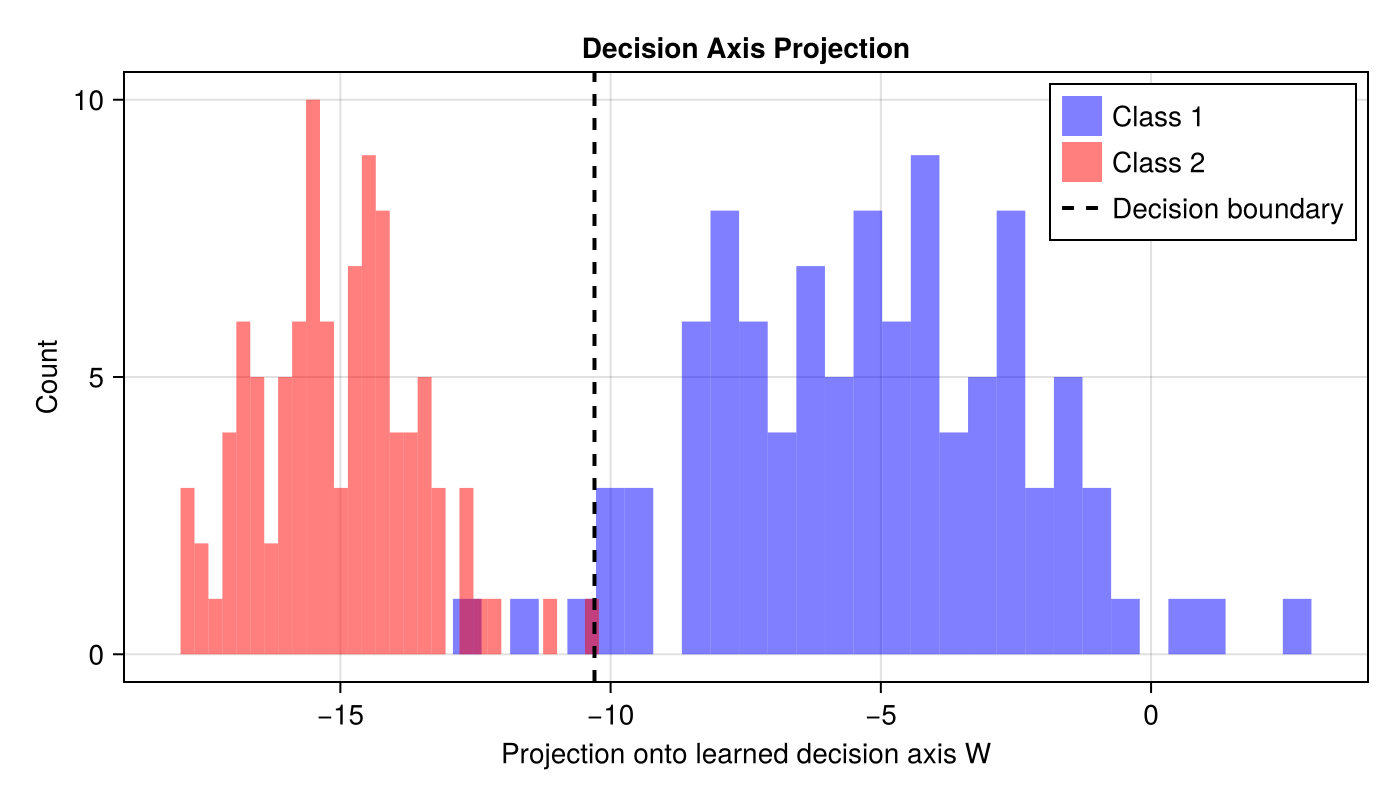

CairoMakie.Screen{IMAGE}


In [81]:
# project onto the 4D discrminating vector to see the classifying histogram 
# The single discriminating direction
w_axis = vec(W[1, :] - W[2, :])
w_axis = w_axis / norm(w_axis)  # normalize

# project all shots onto this axis
proj1 = [dot(w_axis, X1_all[:, i]) for i in 1:size(X1_all, 2)]
proj2 = [dot(w_axis, X2_all[:, i]) for i in 1:size(X2_all, 2)]

# get histogram 
fig = Figure(size=(700, 400))
ax = Axis(fig[1,1],
    xlabel = "Projection onto learned decision axis W",
    ylabel = "Count",
    title  = "Decision Axis Projection")

hist!(ax, proj1, bins=30, color=(:blue, 0.5), label="Class 1")
hist!(ax, proj2, bins=30, color=(:red,  0.5), label="Class 2")

# decision boundary is where W[1,:]*x + b[1] = W[2,:]*x + b[2]
boundary = (b[2] - b[1]) / norm(vec(W[1,:] - W[2,:]))
vlines!(ax, [boundary], color=:black, linestyle=:dash, linewidth=2, label="Decision boundary")

axislegend(ax)
display(fig)